<a href="https://colab.research.google.com/github/neoblazer/DS-Discrete-Mathematices_Practical_Solutions/blob/main/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Merge the 4 Raw Files and Save One **Dataset**

In [ ]:
import pandas as pd
import csv

files = [
    "/content/UNSW_2018_IoT_Botnet_Full5pc_1.csv",
    "/content/UNSW_2018_IoT_Botnet_Full5pc_2.csv",
    "/content/UNSW_2018_IoT_Botnet_Full5pc_3.csv",
    "/content/UNSW_2018_IoT_Botnet_Full5pc_4.csv"
]

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

data.to_csv("bot_iot_merged.csv", index=False)

print("Merged dataset saved successfully")
print("Shape:", data.shape)

/tmp/ipykernel_331/3135663145.py:14: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/tmp/ipykernel_331/3135663145.py:14: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/tmp/ipykernel_331/3135663145.py:14: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/tmp/ipykernel_331/3135663145.py:14: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Merged dataset saved successfully
Shape: (3668522, 46)


# Load the Merged Dataset for **Training**

In [ ]:
import pandas as pd

data = pd.read_csv("/content/bot_iot_merged.csv",low_memory=False)

print(data.shape)

(3668522, 46)


# Remove Non-Numeric **Columns**

In [ ]:
drop_cols = [
    "pkSeqID",
    "saddr",
    "daddr",
    "sport",
    "dport",
    "seq",
    "stime",
    "ltime"
]

data = data.drop(columns=drop_cols, errors="ignore")

# Convert to numeric and Remove NaN

In [ ]:
data = data.apply(pd.to_numeric, errors="ignore")
data=data.dropna()

print(data.shape)
print(data.isnull().sum().sum())

/tmp/ipykernel_331/688568266.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")


(3668522, 38)
0


# Split features and target

In [ ]:
X = data.drop(["attack", "category", "subcategory"], axis=1)

y = data["attack"]

# Encode categorical columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["flgs"] = le.fit_transform(X["flgs"])
X["proto"] = le.fit_transform(X["proto"])
X["state"] = le.fit_transform(X["state"])

# Feature **Scaling**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

# Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(score_func=chi2, k=20)

X = selector.fit_transform(X, y)

# Train-test-split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, stratify=y
)

In [ ]:
print("Train distribution")
print(pd.Series(y_train).value_counts())

print("\nTest distribution")
print(pd.Series(y_test).value_counts())

Train distribution
attack
1    2934435
0        382
Name: count, dtype: int64

Test distribution
attack
1    733610
0        95
Name: count, dtype: int64


# Applying SMOTE (Important for imbalanced data)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

After SMOTE:
attack
1    2934435
0    2934435
Name: count, dtype: int64


# Training the model

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

# Random Search Hyperparameter tuning

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "var_smoothing": np.logspace(0, -9, 100)
}

random_search = RandomizedSearchCV(
    model,
    param_dist,
    n_iter=10,
    cv=3,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameter (Random Search):", random_search.best_params_)

Best parameter (Random Search): {'var_smoothing': np.float64(0.12328467394420659)}


# Grid Search


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "var_smoothing": np.logspace(-9, -7, 20)
}

grid = GridSearchCV(model, param_grid, cv=3)

grid.fit(X_train, y_train)

best_nb = grid.best_estimator_
print("Best parameter (Grid Search):", grid.best_params_)

Best parameter (Grid Search): {'var_smoothing': np.float64(1e-07)}


# Prediction

In [ ]:
y_pred = best_nb.predict(X_test)

# Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9994425552504071
              precision    recall  f1-score   support

           0       0.17      0.83      0.28        95
           1       1.00      1.00      1.00    733610

    accuracy                           1.00    733705
   macro avg       0.58      0.92      0.64    733705
weighted avg       1.00      1.00      1.00    733705



# Confusion Matrix

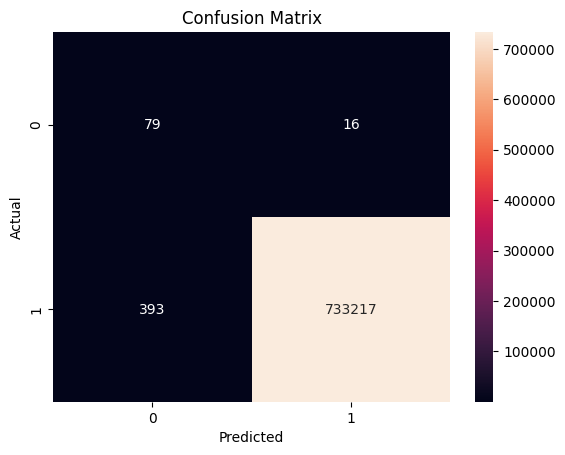

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ROC Curve

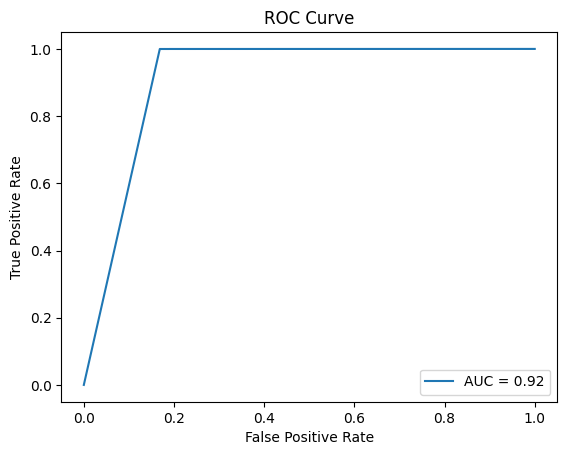

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = best_nb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

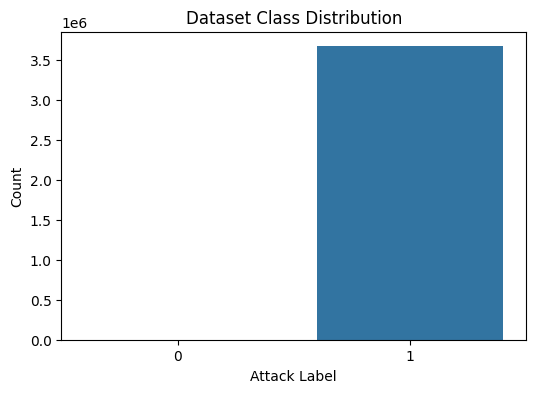

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Dataset Class Distribution")
plt.xlabel("Attack Label")
plt.ylabel("Count")

plt.show()

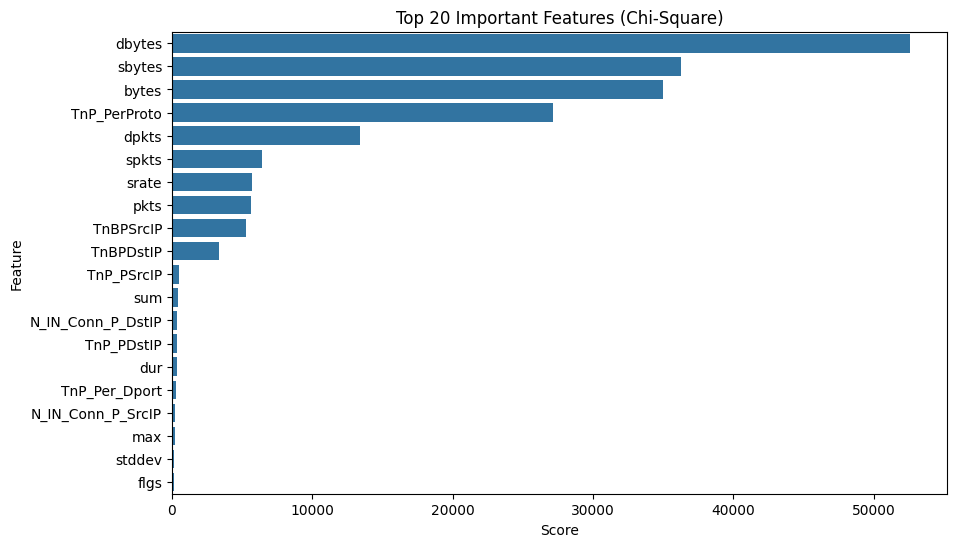

In [ ]:
import pandas as pd

scores = selector.scores_

feature_names = data.drop(["attack","category","subcategory"], axis=1).columns

feature_scores = pd.DataFrame({
    "Feature": feature_names,
    "Score": scores
})

feature_scores = feature_scores.sort_values(by="Score", ascending=False).head(20)

plt.figure(figsize=(10,6))

sns.barplot(x="Score", y="Feature", data=feature_scores)

plt.title("Top 20 Important Features (Chi-Square)")

plt.show()

# Logistic Regression Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

lr_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

param_dist_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "saga"]
}

random_lr = RandomizedSearchCV(
    lr_model,
    param_dist_lr,
    n_iter=4,
    cv=2,
    verbose=2,
    n_jobs=-1
)

random_lr.fit(X_train, y_train)
best_lr = random_lr.best_estimator_

print("Best parameters (Random Search):", random_lr.best_params_)
param_grid_lr = {
    "C": [best_lr.C * 0.5, best_lr.C, best_lr.C * 2]
}

grid_lr = GridSearchCV(
    best_lr,
    param_grid_lr,
    cv=2,
    verbose=2,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

print("Best parameters (Grid Search):", grid_lr.best_params_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best parameters (Random Search): {'solver': 'saga', 'penalty': 'l2', 'C': 1}
Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best parameters (Grid Search): {'C': 2}


# Stocastic Gradient Descent Classifier


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

sgd_model = SGDClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist_sgd = {
    "loss": ["hinge", "log_loss"],   # SVM + Logistic
    "alpha": [0.0001, 0.001, 0.01],
    "penalty": ["l2", "l1"]
}

random_sgd = RandomizedSearchCV(
    sgd_model,
    param_dist_sgd,
    n_iter=5,
    cv=2,
    verbose=2,
    n_jobs=-1
)

random_sgd.fit(X_train, y_train)
best_sgd = random_sgd.best_estimator_

print("Best parameters (Random Search):", random_sgd.best_params_)
param_grid_sgd = {
    "alpha": [best_sgd.alpha / 2, best_sgd.alpha, best_sgd.alpha * 2],
    "loss": [best_sgd.loss]
}

grid_sgd = GridSearchCV(
    best_sgd,
    param_grid_sgd,
    cv=2,
    verbose=2,
    n_jobs=-1
)

grid_sgd.fit(X_train, y_train)
best_sgd = grid_sgd.best_estimator_

print("Best parameters (Grid Search):", grid_sgd.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters (Random Search): {'penalty': 'l2', 'loss': 'hinge', 'alpha': 0.0001}
Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best parameters (Grid Search): {'alpha': 5e-05, 'loss': 'hinge'}


# Predictions for Random Forest and SVM classifiers

In [ ]:
y_pred_nb = best_nb.predict(X_test)
y_pred_lr = best_lr.predict(X_test)
y_pred_sgd = best_sgd.predict(X_test)

# Evalutation of all 3 Classifiers

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Naive Bayes": (best_nb, y_pred_nb),
    "Logistic Regression": (best_lr, y_pred_lr),
    "SGD Classifier": (best_sgd, y_pred_sgd)
}

for name, (model, y_pred) in models.items():
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

import pandas as pd

comparison = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.999443   0.999978  0.999464  0.999721
1  Logistic Regression  0.997017   1.000000  0.997016  0.998506
2       SGD Classifier  0.996748   1.000000  0.996748  0.998371


# Comparision Bar Graph

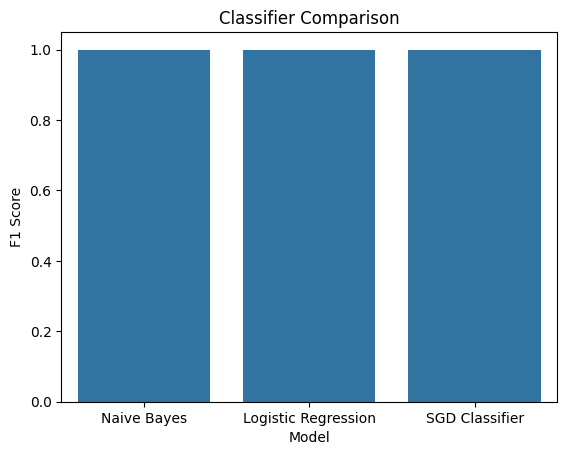

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="F1 Score", data=comparison)
plt.title("Classifier Comparison")
plt.show()